# EECE 5644 Mini Project 1

In [675]:
############################################################

# EECE 5644 - Machine Learning
# Skylar Denno
# June 30, 2026

# MINI PROJECT 1
# Data cleaning and data preprocessing

############################################################

In [676]:
import sys, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.2f}".format)
np.random.seed(0)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

In [677]:
### 3.2 Getting Information

# load raw dataset from csv
raw_df = pd.read_csv("data.csv", encoding="ISO-8859-1")
print("\nLoaded dataset with", raw_df.shape[0], "rows")

# class
class GettingInfo:
    def __init__(self):
        pass

    def print_basic_description(self, df):
        print("\n\n--------------------\nBASIC INFORMATION\n--------------------")
        print("\nShape:", df.shape)
        print("\nInfo:", df.info())
        print("\nStatistical Description:", df.describe())
        print("\nHead (first 10 rows):", df.head(10))

basic_info = GettingInfo()
basic_info.print_basic_description(raw_df)


Loaded dataset with 541909 rows


--------------------
BASIC INFORMATION
--------------------

Shape: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Info: None

Statistical Description:        Quantity  UnitPrice  CustomerID
count 541909.00  541909.00   406829.00
mean       9.55       4.61    15287.69
std      218.08      96.76     1713.60
min   -80995.00  -11062.06    12346.00
25%        1.00       1.25    13953.00
50%       

In [678]:
### 3.9 Unique Values

class UniqueValues:
    def __init__(self):
        pass

    def print_unique_values(self, df):
        print("\n\n--------------------\nUNIQUE VALUES/COUNTS\n--------------------")
        print("\nNum. of countries: ", df["Country"].nunique())
        print("\nNum. of instances of each country present: ", df["Country"].value_counts())

        print("\nNum. of stock codes: ", df["StockCode"].nunique())
        print("\nNum. of stock codes (INCLU. MISSING): ", df["StockCode"].nunique(dropna=False))
        print("\nNum. of instances of each stock code: ", df["StockCode"].value_counts())
        print("\nNum. of instances of each stock code (INCLU. MISSING):")
        print(df["StockCode"].value_counts(dropna=False))

        print("\nNum. of unique product descriptions:", df["Description"].nunique())
        print("\nNum. of instances of each product description", df["Description"].value_counts())

unique_values = UniqueValues()
unique_values.print_unique_values(raw_df)



--------------------
UNIQUE VALUES/COUNTS
--------------------

Num. of countries:  38

Num. of instances of each country present:  Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece               

In [679]:
### 3.8 Min/max/sum/mean/count

class NumericSummary:
    def __init__(self):
        pass

    def print_numeric_summary(self, df):
        print("\n\n--------------------\nNUMERIC SUMMARY\n--------------------")
        summary = df[["Quantity", "UnitPrice"]].agg(["min", "max", "sum", "mean", "count"])
        print(summary)

numeric_summary = NumericSummary()
numeric_summary.print_numeric_summary(raw_df)



--------------------
NUMERIC SUMMARY
--------------------
        Quantity  UnitPrice
min    -80995.00  -11062.06
max     80995.00   38970.00
sum   5176450.00 2498803.97
mean        9.55       4.61
count  541909.00  541909.00


In [680]:
### 3.1 Creating a DataFrame

class CountryRegionLookup:
    def __init__(self):
        self.country_region_lookup = None

    def build_country_region_lookup(self):
        """Returns a DataFrame with columns ['country', 'region']."""
        country_region_data = [
            ("United Kingdom", "UK & IE"),
            ("Germany", "Western Europe"),
            ("France", "Western Europe"),
            ("Spain", "Western Europe"),
            ("Netherlands", "Western Europe"),
            ("Belgium", "Western Europe"),
            ("Switzerland", "Western Europe"),
            ("Portugal", "Western Europe"),
            ("Australia", "Oceania"),
            ("Norway", "Northern Europe"),
            ("Italy", "Southern Europe"),
            ("Channel Islands", "Western Europe"),
            ("Finland", "Northern Europe"),
            ("Cyprus", "Mediterranean"),
            ("Sweden", "Northern Europe"),
            ("Austria", "Western Europe"),
            ("Denmark", "Northern Europe"),
            ("Japan", "Asia Pacific"),
            ("Poland", "Central Europe"),
            ("Israel", "Middle East"),
            ("USA", "North America"),
            ("Hong Kong", "Asia Pacific"),
            ("Singapore", "Asia Pacific"),
            ("Iceland", "Northern Europe"),
            ("Canada", "North America"),
            ("Greece", "Southern Europe"),
            ("Malta", "Southern Europe"),
            ("United Arab Emirates", "Middle East"),
            ("Lebanon", "Middle East"),
            ("Lithuania", "Eastern Europe"),
            ("Brazil", "South America"),
            ("Czech Republic", "Central Europe"),
            ("Bahrain", "Middle East"),
            ("Saudi Arabia", "Middle East"),
            ("RSA", "Africa"),
            ("ERIE", "Ireland"),
            ("European Community", "GENERAL EUROPE"),
            ("Unspecified", "UNSPECIFIED")
        ]

        self.country_region_lookup = pd.DataFrame(country_region_data, columns=["country", "region"])
        return self.country_region_lookup

country_lookup = CountryRegionLookup()
region_df = country_lookup.build_country_region_lookup()
print(region_df)


                 country           region
0         United Kingdom          UK & IE
1                Germany   Western Europe
2                 France   Western Europe
3                  Spain   Western Europe
4            Netherlands   Western Europe
5                Belgium   Western Europe
6            Switzerland   Western Europe
7               Portugal   Western Europe
8              Australia          Oceania
9                 Norway  Northern Europe
10                 Italy  Southern Europe
11       Channel Islands   Western Europe
12               Finland  Northern Europe
13                Cyprus    Mediterranean
14                Sweden  Northern Europe
15               Austria   Western Europe
16               Denmark  Northern Europe
17                 Japan     Asia Pacific
18                Poland   Central Europe
19                Israel      Middle East
20                   USA    North America
21             Hong Kong     Asia Pacific
22             Singapore     Asia 

In [681]:
# start of cleaning -> make a copy of raw dataframe to clean
clean_df = raw_df.copy()

### 3.3 Slicing
class SliceRows:
    def __init__(self):
        pass

    def slice_rows(self, df):
        df = df.copy()
        df.index = [f"item_{i}" for i in range(len(df))]

        print("\n\n--------------------\nSLICING WITH ILOC AND LOC\n--------------------")
        print("\nFirst 5 rows with iloc:")
        print(df.iloc[0:5])

        labels = [f"item_{i}" for i in range(5)]
        print("\nRows retrieved by label with loc:")
        print(df.loc[labels])
        return df

slicer = SliceRows()
clean_df = slicer.slice_rows(clean_df)




--------------------
SLICING WITH ILOC AND LOC
--------------------

First 5 rows with iloc:
       InvoiceNo StockCode                          Description  Quantity  \
item_0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
item_1    536365     71053                  WHITE METAL LANTERN         6   
item_2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
item_3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
item_4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
item_0  12/1/2010 8:26       2.55    17850.00  United Kingdom  
item_1  12/1/2010 8:26       3.39    17850.00  United Kingdom  
item_2  12/1/2010 8:26       2.75    17850.00  United Kingdom  
item_3  12/1/2010 8:26       3.39    17850.00  United Kingdom  
item_4  12/1/2010 8:26       3.39    17850.00  United Kingdom  

Rows retrieved by label with loc:
       InvoiceNo StockC

In [682]:
### 3.4 Conditional Selection
# THIS ALSO DELETES THOSE ROWS

class FilterCanceled:
    def __init__(self):
        pass

    def remove_canceled_orders(self, df):
        df = df.copy()
        df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
        return df

canceled_remover = FilterCanceled()
clean_df = canceled_remover.remove_canceled_orders(clean_df)

In [683]:
### 3.5 Sorting Values && 3.18 Applying a Function
# NOTE: THIS CLASS ALSO ADDS THE REVENUE COLUMN TO THE DATAFRAME.

class LargestOrders:
    def __init__(self):
        pass

    def find_largest_orders(self, df, top_n=5):
        df = df.copy()

        #########
        df["revenue"] = df["Quantity"] * df["UnitPrice"]
        #########

        print("\n\n--------------------\nTOP BULK ORDERS BY QUANTITY\n--------------------")
        print(df.sort_values("Quantity", ascending=False).head(top_n)[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "revenue"]])

        print("\n\n--------------------\nTOP ORDERS BY REVENUE\n--------------------")
        print(df.sort_values("revenue", ascending=False).head(top_n)[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "revenue"]])

        print("\n\n--------------------\nTOP RETURNS BY NEGATIVE QUANTITY\n--------------------")
        returns = df[df["Quantity"] < 0]
        print(returns.sort_values(["Quantity", "revenue"], ascending=[True, True]).head(top_n)[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice", "revenue"]])

        return df.sort_values(["Quantity", "revenue"], ascending=[False, False])

largest_orders = LargestOrders()
clean_df = largest_orders.find_largest_orders(clean_df)



--------------------
TOP BULK ORDERS BY QUANTITY
--------------------
            InvoiceNo StockCode                        Description  Quantity  \
item_540421    581483     23843        PAPER CRAFT , LITTLE BIRDIE     80995   
item_61619     541431     23166     MEDIUM CERAMIC TOP STORAGE JAR     74215   
item_502122    578841     84826     ASSTD DESIGN 3D PAPER STICKERS     12540   
item_74614     542504     37413                                NaN      5568   
item_421632    573008     84077  WORLD WAR 2 GLIDERS ASSTD DESIGNS      4800   

             UnitPrice   revenue  
item_540421       2.08 168469.60  
item_61619        1.04  77183.60  
item_502122       0.00      0.00  
item_74614        0.00      0.00  
item_421632       0.21   1008.00  


--------------------
TOP ORDERS BY REVENUE
--------------------
            InvoiceNo  StockCode                     Description  Quantity  \
item_540421    581483      23843     PAPER CRAFT , LITTLE BIRDIE     80995   
item_61619     

In [684]:
### 3.6 Replacing Values

class ReplaceVals:
    def __init__(self):
        pass

    def replace_values(self, df):
        df = df.copy()
        df["Country"] = df["Country"].replace({
            "EIRE": "Ireland",
            "RSA": "South Africa",
            "Unspecified": "MISSING"
        })
        return df

clean_df = ReplaceVals().replace_values(clean_df)

In [685]:
### 3.7 Renaming Columns

class RenameColumns:
    def __init__(self):
        pass

    def rename_columns(self, df):
        df = df.copy()
        df = df.rename(columns={
            "InvoiceNo": "invoice_no",
            "StockCode": "stock_code",
            "Description": "description",
            "Quantity": "quantity",
            "InvoiceDate": "invoice_date",
            "UnitPrice": "unit_price",
            "CustomerID": "customer_id",
            "Country": "country"
        })
        return df

clean_df = RenameColumns().rename_columns(clean_df)

In [686]:
### 3.10 Handle Missing Values

# My reasoning: Using a chi-square test, we check if missingness (description) is associated with other variables
# or if it is not very associated with other values and therefore likely just by random chance.
# We use a standard cutoff of alpha=0.05 to determine if missingness is related to other variables.
# p-value > 0.05 --> Assume MCAR and discard this row
# KEEP MAR AND MNAR. DISCARD MCAR

# For missing customerID, it appears to be random and not at all related to any other column, (max p val = 0) so 
# my guess is that these are just unregistered customers ("Checkout as a guest"). So I keep the missing
# customerID rows, but set the customer ID to 0 so it is a number, so any future isna/isnull calls will not delete them.

from scipy.stats import ttest_ind

class RemoveMCAR:
    def __init__(self):
        pass

    def findMCAR(self, df):
        df = df.copy()
        target_cols = [col for col in ["description", "customer_id"] if col in df.columns]

        for col in target_cols:
            if df[col].isnull().sum() == 0: # isnull example
                continue

            missing_indicator = df[col].isnull().astype(int)
            p_values = []

            for feature in ["quantity", "unit_price"]:
                if feature in df.columns:
                    present = df.loc[missing_indicator == 0, feature].dropna() # dropna example
                    missing = df.loc[missing_indicator == 1, feature].dropna()
                    if len(present) > 1 and len(missing) > 1:
                        _, p = ttest_ind(present, missing, equal_var=False)
                        p_values.append((feature, p))

            if "country" in df.columns:
                country_present = df.loc[missing_indicator == 0, "country"]
                country_missing = df.loc[missing_indicator == 1, "country"]
                if len(country_present) > 1 and len(country_missing) > 1:
                    from scipy.stats import chi2_contingency
                    crosstab = pd.crosstab(missing_indicator, df["country"])
                    _, p, _, _ = chi2_contingency(crosstab)
                    p_values.append(("country", p))

            if p_values:
                p_value_summary = ", ".join(f"{feature}={p:.4f}" for feature, p in p_values)
                print(f"{col}: p-values -> {p_value_summary}")
                max_p = max(p for _, p in p_values)
                print(f"{col}: highest p-value = {max_p:.4f}")
                if max_p > 0.05:
                    print(f"{col}: MCAR trigger -> rows with missing {col} will be removed")
                    df = df.dropna(subset=[col])

        return df

"""
### TESTS DESIGNED TO GIVE P VALUES ABOVE 0.05
np.random.seed(0)

# missing discriptions
test_df_1 = pd.DataFrame({
    "description": ["a", "b", None, None, "c", "d", None, None],
    "quantity": [1, 2, 1.1, 2.1, 3, 4, 3.2, 4.1],
    "unit_price": [10, 11, 10.2, 11.1, 12, 13, 12.1, 13.2],
    "country": ["UK", "UK", "US", "US", "UK", "UK", "US", "US"]
})

# missing customer_ids
test_df_2 = pd.DataFrame({
    "customer_id": [101, 102, None, None, 105, 106, None, None],
    "quantity": [2, 3, 2.1, 3.1, 4, 5, 4.1, 5.1],
    "unit_price": [20, 21, 20.2, 21.1, 22, 23, 22.1, 23.2],
    "country": ["US", "US", "UK", "UK", "US", "US", "UK", "UK"]
})

print("Test dataframe 1 result:")
print(RemoveMCAR().findMCAR(test_df_1))
print("\nTest dataframe 2 result:")
print(RemoveMCAR().findMCAR(test_df_2))
### END TESTS
"""

clean_df = RemoveMCAR().findMCAR(clean_df)

# FILLNA missing customer_id with 0 - UNREGISTERED CUSTOMERS?
clean_df["customer_id"] = clean_df["customer_id"].fillna(0) # fillna example

description: p-values -> quantity=0.0021, unit_price=0.0000, country=0.0000
description: highest p-value = 0.0021
customer_id: p-values -> quantity=0.0000, unit_price=0.0000, country=0.0000
customer_id: highest p-value = 0.0000


In [687]:
### 3.11 Delete Column

# My reasoning: invoice number is not relevant to my analysis, and it doesn't really mean anything in the "trends"
# the business questions are asking about. They are for the company's internal use to track orders, and
# they are unrelated to who the customer actually is; they could be completely random as far as we are concerned.
# We have already deleted the canceled orders so it has no more useful data.

# I thought initially description could be removed, reasoning that it was redundant with stock code.
# However, we see with nunique above that there are more unique descriptions than stock codes, so they are not
# exchangable or 1-to-1. Therefore, there is some more complex relationship between stock code and description
# so both are kept.

class DeleteColumn:
    def __init__(self):
        pass

    def drop_column(self, df, column_name):
        df = df.copy()
        if column_name in df.columns:
            df = df.drop(columns=[column_name])
            print(f"Dropped column: {column_name}")
        else:
            print(f"Column not found: {column_name}")
        return df

clean_df = DeleteColumn().drop_column(clean_df, "invoice_no")

Dropped column: invoice_no


In [ ]:
### 3.12 Delete Row
# Quantity <= 0 means a non-sale or a return
# Price <= 0 doesn't make sense
# Stock code "POST" reports postage cost, which I assume the company is not "selling" as a product like
# everything else.

class DeleteBadRows:
    def __init__(self):
        pass

    def remove_bad_rows(self, df):
        df = df.copy()
        before = len(df)
        df = df[df["quantity"] != 0]
        df = df[df["unit_price"] > 0]
        df = df[df["stock_code"] != "POST"]
        after = len(df)
        print(f"Removed {before - after} bad rows")
        return df

bad_row_remover = DeleteBadRows()
sales = bad_row_remover.remove_bad_rows(clean_df)

Removed 3643 bad rows


In [689]:
### 3.17 Looping over a column
# I am just using the upper function (a random function) while iterating through the countries column
# in 3 different ways, using upper on each value. I time each method to confirm apply is faster
import time

country_list = sales["country"]

# --- for-loop over a Series ---
start = time.perf_counter()
loop_series_result = []
for val in sales["country"]:
    loop_series_result.append(val.upper())
loop_series_time = time.perf_counter() - start
print(f"for-loop: {loop_series_time:.4f} s")

# --- list comprehension over a Series ---
start = time.perf_counter()
comp_series_result = [val.upper() for val in sales["country"]]
comp_series_time = time.perf_counter() - start
print(f"list comp: {comp_series_time:.4f} s")

# --- pandas apply ---
start = time.perf_counter()
apply_result = sales["country"].apply(str.upper)
apply_time = time.perf_counter() - start
print(f"apply : {apply_time:.4f} s")

# EXPLAINATION:
# When working with data, usually Series are better than lists, since series keep track of indexes of items
# whereas with lists, rows could be swapped, and their position (the only way th find them again) lost.
# We need to use Series which is part of pandas, so using apply, which is also from pandas is faster since
# it doesn't need to go from standard python objects into a Series wrapper and then back again, which saves time.


for-loop: 0.0286 s
list comp: 0.0199 s
apply : 0.0188 s


In [690]:
### 3.14 Grouping by Values

# revenue by country
revenue_by_country = (
    sales
    .groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
)
print("Revenue by country:")
print(revenue_by_country)

# num of orders per person
orders_per_customer = (
    sales
    .groupby("customer_id")
    .size()
    .rename("order_count")
    .sort_values(ascending=False)
)
print("\nOrders per customer:")
print(orders_per_customer)


Revenue by country:
country
United Kingdom         9016315.14
Netherlands             283889.34
Ireland                 283453.96
Germany                 207866.14
France                  194261.11
Australia               138171.31
Spain                    55725.11
Switzerland              53087.90
Japan                    37416.37
Belgium                  36927.34
Sweden                   36869.33
Norway                   33294.94
Portugal                 31239.10
Singapore                21279.29
Channel Islands          20450.44
Finland                  18896.08
Denmark                  18211.34
Italy                    15820.24
Hong Kong                15516.80
Cyprus                   13575.38
Austria                   8742.68
Israel                    8135.26
Poland                    6974.65
MISSING                   4749.79
Greece                    4425.52
Iceland                   4310.00
USA                       3580.39
Canada                    3115.44
Malta               

In [691]:
### 3.16 Aggregating

# multiple stats per country
country_stats = (
    sales
    .groupby("country")["revenue"]
    .agg(
        total_revenue="sum",
        mean_order_value="mean",
        transaction_count="count"
    )
    .sort_values("total_revenue", ascending=False)
)
print("Stats per country:")
print(country_stats)

# multiple stats per customer
customer_stats = (
    sales
    .groupby("customer_id")["revenue"]
    .agg(
        total_revenue="sum",
        mean_order_value="mean",
        transaction_count="count"
    )
    .sort_values("total_revenue", ascending=False)
)
print("\nStats per customer:")
print(customer_stats)


Stats per country:
                      total_revenue  mean_order_value  transaction_count
country                                                                 
United Kingdom           9016315.14             18.59             485071
Netherlands               283889.34            122.26               2322
Ireland                   283453.96             35.93               7890
Germany                   207866.14             23.99               8666
France                    194261.11             23.96               8107
Australia                 138171.31            117.00               1181
Spain                      55725.11             23.01               2422
Switzerland                53087.90             27.44               1935
Japan                      37416.37            116.56                321
Belgium                    36927.34             19.08               1935
Sweden                     36869.33             85.94                429
Norway                     33294

In [692]:
### 3.19 Applying to groups

# parse invoice_date once so the custom function can use it
sales["invoice_date"] = pd.to_datetime(sales["invoice_date"]) # ALREADY PARSES DATES TO DATETIME

def customer_summary(group):
    total_spend = group["revenue"].sum()

    # for active months, find the number of unique months in which the customer made purchases
    active_months = group["invoice_date"].dt.to_period("M").nunique()
    return pd.Series({
        "total_spend": total_spend,
        "active_months": active_months,
    })


customer_profile = (
    sales
    .groupby("customer_id")
    .apply(customer_summary, include_groups=False)
    .sort_values("total_spend", ascending=False)
)
print("Custom per-customer summary:")
print(customer_profile)


Custom per-customer summary:
             total_spend  active_months
customer_id                            
0.00          1754978.72          13.00
14646.00       279138.02          13.00
18102.00       259657.30          12.00
17450.00       194550.79          12.00
16446.00       168472.50           2.00
...                  ...            ...
16878.00           13.30           1.00
17956.00           12.75           1.00
16454.00            6.90           1.00
14792.00            6.20           1.00
16738.00            3.75           1.00

[4339 rows x 2 columns]


Monthly revenue:
invoice_date
2010-12-31    819316.14
2011-01-31    686226.13
2011-02-28    520465.89
2011-03-31    712301.79
2011-04-30    534398.67
2011-05-31    757177.27
2011-06-30    756203.42
2011-07-31    713896.54
2011-08-31    753779.78
2011-09-30   1052692.95
2011-10-31   1146953.34
2011-11-30   1499143.35
2011-12-31    636027.39
Freq: ME, Name: revenue, dtype: float64

Weekly revenue:
invoice_date
2010-12-05   184564.83
2010-12-12   328306.81
2010-12-19   214645.20
2010-12-26    91799.30
2011-01-02        0.00
2011-01-09   132576.19
2011-01-16   191966.04
2011-01-23   214269.75
2011-01-30   124148.79
2011-02-06   124630.68
2011-02-13   106570.70
2011-02-20   143091.46
2011-02-27   147982.78
2011-03-06   131822.55
2011-03-13   134813.91
2011-03-20   160561.62
2011-03-27   147573.47
2011-04-03   191120.53
2011-04-10   133846.88
2011-04-17   148615.73
2011-04-24   140880.98
2011-05-01    85750.08
2011-05-08   137885.85
2011-05-15   210552.26
2011-05-22   214697.32
2011-05-29   

/var/folders/3l/bx4jxjpn2pq9d9vwtg2r7fvw0000gn/T/ipykernel_40550/4033576664.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = ts["revenue"].resample("M").sum()


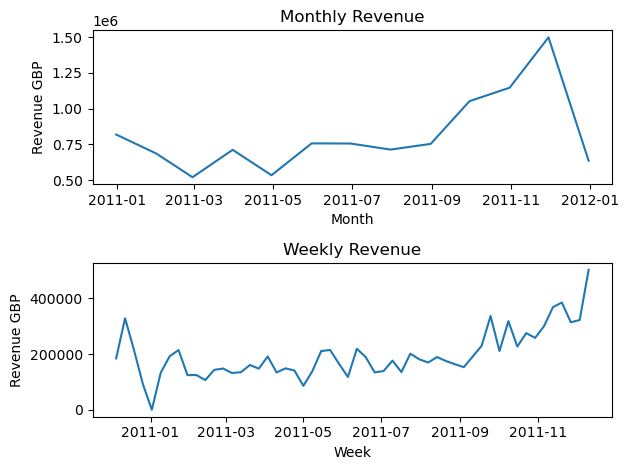

In [693]:
### 3.15 Grouping by time

# invoice_date was already parsed above with groupby().apply()
ts = sales.set_index("invoice_date").sort_index()

# monthly rev
monthly_revenue = ts["revenue"].resample("M").sum()
print("Monthly revenue:")
print(monthly_revenue)

# weekly
weekly_revenue = ts["revenue"].resample("W").sum()
print("\nWeekly revenue:")
print(weekly_revenue)

# plot
fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.plot(monthly_revenue.index, monthly_revenue.values)
ax1.set_title("Monthly Revenue")
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue GBP")

ax2.plot(weekly_revenue.index, weekly_revenue.values)
ax2.set_title("Weekly Revenue")
ax2.set_xlabel("Week")
ax2.set_ylabel("Revenue GBP")

plt.tight_layout()
plt.show()


In [694]:
### 3.20 Concatenating

h1 = sales[sales["invoice_date"].dt.month <= 6].copy() # jan to jun
h2 = sales[sales["invoice_date"].dt.month >= 7].copy() # jul to dec

print(f"Half 1: {len(h1):,} rows")
print(f"Half 2: {len(h2):,} rows")

combined = pd.concat([h1, h2], ignore_index=True)

print(f"\nCombined: {len(combined):,} rows")

print(len(h1) + len(h2))


Half 1: 198,009 rows
Half 2: 330,969 rows

Combined: 528,978 rows
528978


In [695]:
### 3.21 Merging

# inner join: only rows whose country appears in the lookup table
inner = sales.merge(region_df, on="country", how="inner")

# left join: all sales rows kept; unmatched countries get kept with NaN as region (the "default" action)
left = sales.merge(region_df, on="country", how="left")

print(f"sales rows: {len(sales):,}")
print(f"inner join: {len(inner):,} rows  ({len(sales) - len(inner):,} dropped)")
print(f"left join: {len(left):,} rows  ({left['region'].isnull().sum():,} with NaN region)")

# failed matches (left join items with NaN region)
unmatched = (
    left[left["region"].isnull()]["country"]
    .value_counts()
    .rename("row_count")
)
print("\nCountries that failed to match the lookup table:")
print(unmatched)

# Explaination: 
# The inner join keeps only the rows when the country exists in the lookup table, removing unmatched rows.
# The left join keeps all rows, but for countries not in the lookup table, the region col will have NaN values.
# The unmatched countries are identified by filtering the left join result for rows with NaN region.


sales rows: 528,978
inner join: 520,585 rows  (8,393 dropped)
left join: 528,978 rows  (8,393 with NaN region)

Countries that failed to match the lookup table:
country
Ireland         7890
MISSING          446
South Africa      57
Name: row_count, dtype: int64


In [696]:
### Export

# write cleaned data
output_path = "clean_online_retail.csv"
sales.to_csv(output_path, index=False)
print(f"Saved clean data output to {output_path}")

# data dict
data_dict = pd.DataFrame([
    ("stock_code","object","Unique product ID"),
    ("description","object","Product name"),
    ("quantity","int64","Number sold of specific product"),
    ("invoice_date","datetime","Time of purchase"),
    ("unit_price","float64","Price per unit in GBP"),
    ("customer_id","float64","Unique customer ID"),
    ("country","object","Customer country"),
    ("revenue","float64","Quantity × unit_price"),
], columns=["column", "dtype", "description"])

output_path = "data_dictionary.csv"
data_dict.to_csv(output_path, index=False)


Saved clean data output to clean_online_retail.csv


In [697]:
cleaned_info = GettingInfo()
cleaned_vals = UniqueValues()
cleaned_info.print_basic_description(sales)



--------------------
BASIC INFORMATION
--------------------

Shape: (528978, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 528978 entries, item_540421 to item_361741
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   stock_code    528978 non-null  object        
 1   description   528978 non-null  object        
 2   quantity      528978 non-null  int64         
 3   invoice_date  528978 non-null  datetime64[ns]
 4   unit_price    528978 non-null  float64       
 5   customer_id   528978 non-null  float64       
 6   country       528978 non-null  object        
 7   revenue       528978 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 52.4+ MB

Info: None

Statistical Description:        quantity                   invoice_date  unit_price  customer_id  \
count 528978.00                         528978   528978.00    528978.00   
mean      10.56  2